# 🛒 Online Retail Customer Segmentation — ML Pipeline

**Problem Statement:**  
Segment customers of an online retail store based on their purchase behavior using **RFM Analysis** (Recency, Frequency, Monetary Value) and unsupervised clustering algorithms.

**Dataset:** [Online Retail Dataset — Kaggle](https://www.kaggle.com/datasets/lakshmi25npathi/online-retail-dataset)  
*(UCI ML Repository: transactions from a UK-based online retail store, Dec 2010 – Dec 2011)*

---

### 📋 ML Pipeline Overview
1. Data Collection (load from URL / Kaggle)
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing & Cleaning
4. Feature Engineering — RFM Metrics
5. Outlier Removal & Scaling
6. Model Training — KMeans, Hierarchical, DBSCAN
7. Model Evaluation — Silhouette Score, Elbow Method
8. Dimensionality Reduction — PCA & t-SNE
9. Cluster Profiling & Business Insights

## Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & Scaling
from sklearn.preprocessing import StandardScaler, RobustScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Cluster Evaluation
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Dimensionality Reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Dendrogram for Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
PALETTE = 'tab10'

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Step 2 — Data Collection

The dataset is hosted on the UCI ML Repository and also available on Kaggle.  
We load it directly from the UCI URL (Excel format).  

**Columns:**
| Column | Description |
|--------|-------------|
| InvoiceNo | Invoice number (C prefix = cancellation) |
| StockCode | Product code |
| Description | Product name |
| Quantity | Units per transaction |
| InvoiceDate | Date & time of invoice |
| UnitPrice | Price per unit (GBP £) |
| CustomerID | Unique customer identifier |
| Country | Country of customer |

In [2]:
# Load directly from UCI ML Repository (Excel format)
# Alternative: download from Kaggle and use pd.read_excel('Online Retail.xlsx')

#url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
file_path = "D:\\Base\\COMP\\Code\\PY\\ML\\Calfus_Training\\Online Retail.xlsx"

print('⏳ Loading dataset from UCI ML Repository...')
df = pd.read_excel(file_path)

print(f'✅ Dataset loaded! Shape: {df.shape}')
df.head()

⏳ Loading dataset from UCI ML Repository...
✅ Dataset loaded! Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Step 3 — Exploratory Data Analysis (EDA)

In [3]:
# Basic shape and data types
print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
print('\nDescriptive Statistics:')
df.describe()

Shape: (541909, 8)

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Descriptive Statistics:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [4]:
# Missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing Values:')
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values:
             Missing Count  Missing %
Description           1454   0.268311
CustomerID          135080  24.926694


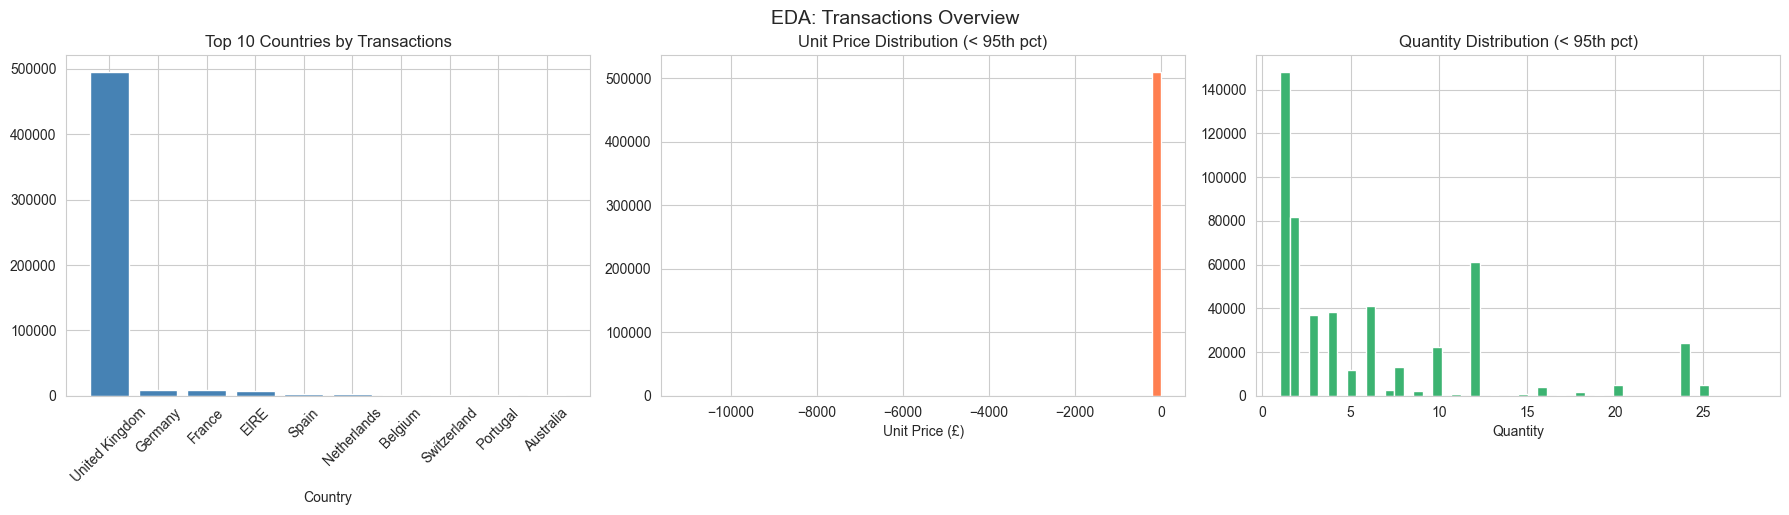

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top 10 countries by transaction count
top_countries = df['Country'].value_counts().head(10)
axes[0].bar(top_countries.index, top_countries.values, color='steelblue')
axes[0].set_title('Top 10 Countries by Transactions')
axes[0].set_xlabel('Country')
axes[0].tick_params(axis='x', rotation=45)

# Distribution of UnitPrice (capped at 95th percentile for readability)
price_cap = df['UnitPrice'].quantile(0.95)
axes[1].hist(df[df['UnitPrice'] < price_cap]['UnitPrice'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Unit Price Distribution (< 95th pct)')
axes[1].set_xlabel('Unit Price (£)')

# Distribution of Quantity (capped at 95th percentile)
qty_cap = df['Quantity'].quantile(0.95)
axes[2].hist(df[(df['Quantity'] > 0) & (df['Quantity'] < qty_cap)]['Quantity'],
             bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Quantity Distribution (< 95th pct)')
axes[2].set_xlabel('Quantity')

plt.tight_layout()
plt.suptitle('EDA: Transactions Overview', fontsize=14, y=1.02)
plt.show()

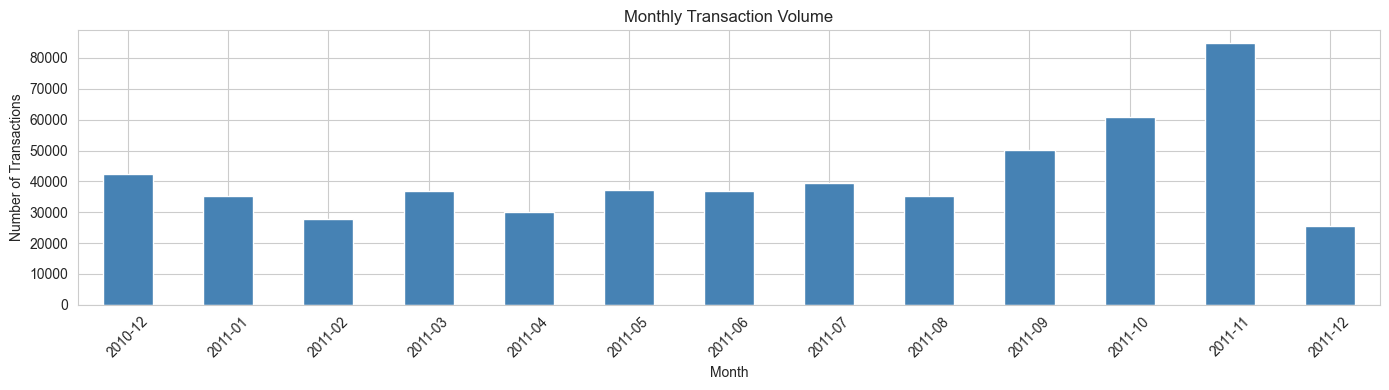

In [6]:
# Transactions over time (monthly)
df_temp = df.copy()
df_temp['InvoiceDate'] = pd.to_datetime(df_temp['InvoiceDate'])
df_temp['Month'] = df_temp['InvoiceDate'].dt.to_period('M')

monthly = df_temp.groupby('Month').size()

plt.figure(figsize=(14, 4))
monthly.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Monthly Transaction Volume')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 4 — Data Preprocessing & Cleaning

Before computing RFM, we must clean the data:
- **Remove rows with missing CustomerID** — can't assign RFM without a customer
- **Remove cancellations** — InvoiceNo starting with 'C'
- **Remove rows with Quantity ≤ 0 or UnitPrice ≤ 0** — invalid transactions
- **Parse InvoiceDate** as datetime

In [7]:
df_clean = df.copy()

# 1. Parse InvoiceDate as datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 2. Drop rows with missing CustomerID (no customer = no RFM)
before = len(df_clean)
df_clean.dropna(subset=['CustomerID'], inplace=True)
print(f'Rows removed (missing CustomerID): {before - len(df_clean)}')

# 3. Remove cancelled transactions (InvoiceNo starts with 'C')
before = len(df_clean)
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print(f'Rows removed (cancellations): {before - len(df_clean)}')

# 4. Remove invalid Quantity and UnitPrice
before = len(df_clean)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
print(f'Rows removed (invalid Qty/Price): {before - len(df_clean)}')

# 5. Compute TotalPrice per line item
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f'\n✅ Clean dataset shape: {df_clean.shape}')
df_clean.head()

Rows removed (missing CustomerID): 135080
Rows removed (cancellations): 8905
Rows removed (invalid Qty/Price): 40

✅ Clean dataset shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Step 5 — Feature Engineering: RFM Analysis

**RFM** is a behavioral segmentation framework built on three dimensions:

| Metric | Definition | Business Meaning |
|--------|-----------|------------------|
| **Recency (R)** | Days since last purchase | Lower = more engaged |
| **Frequency (F)** | Number of distinct invoices | Higher = more loyal |
| **Monetary (M)** | Total spend (£) | Higher = more valuable |

We use a **snapshot date** = 1 day after the last invoice in the dataset, so recency is computed relative to the "present" of the dataset.

In [8]:
# Snapshot date: 1 day after the last recorded transaction
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Snapshot Date: {snapshot_date.date()}')

# Compute RFM per customer
rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

rfm['CustomerID'] = rfm['CustomerID'].astype(int)

print(f'\nRFM Table Shape: {rfm.shape}')
rfm.describe()

Snapshot Date: 2011-12-10

RFM Table Shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


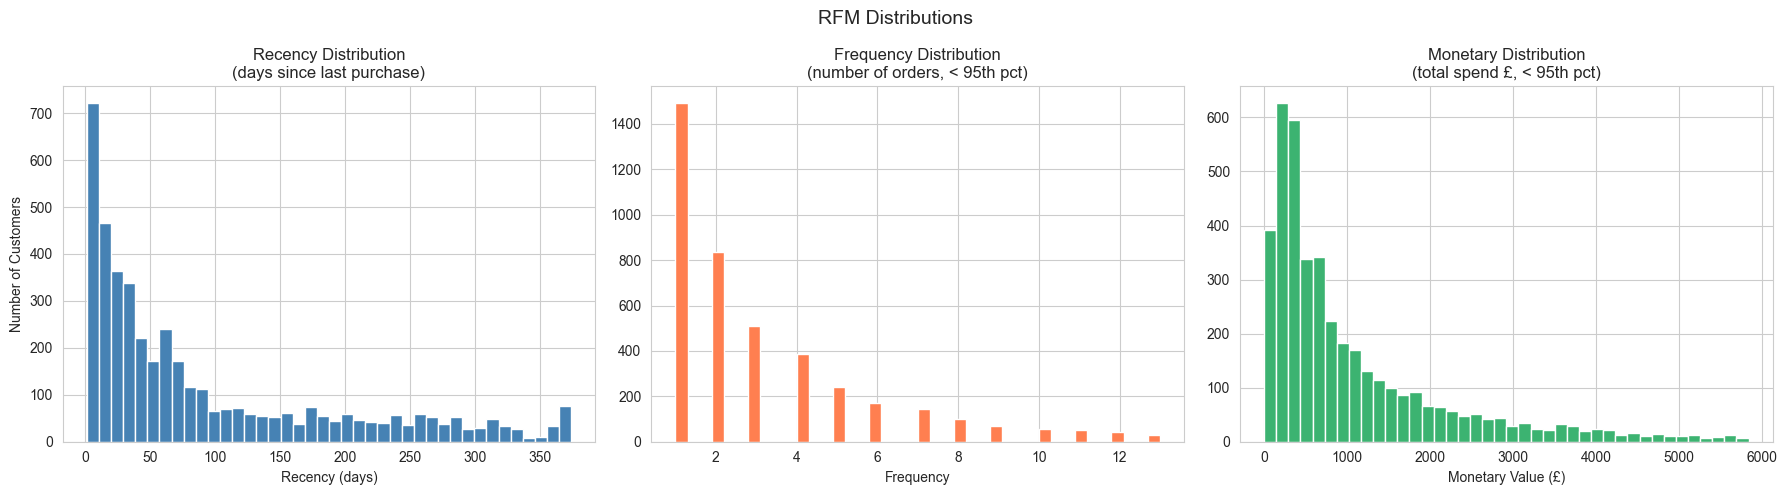

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency distribution
axes[0].hist(rfm['Recency'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Recency Distribution\n(days since last purchase)')
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Number of Customers')

# Frequency distribution (capped for readability)
freq_cap = rfm['Frequency'].quantile(0.95)
axes[1].hist(rfm[rfm['Frequency'] <= freq_cap]['Frequency'],
             bins=40, color='coral', edgecolor='white')
axes[1].set_title('Frequency Distribution\n(number of orders, < 95th pct)')
axes[1].set_xlabel('Frequency')

# Monetary distribution (capped)
mon_cap = rfm['Monetary'].quantile(0.95)
axes[2].hist(rfm[rfm['Monetary'] <= mon_cap]['Monetary'],
             bins=40, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Monetary Distribution\n(total spend £, < 95th pct)')
axes[2].set_xlabel('Monetary Value (£)')

plt.suptitle('RFM Distributions', fontsize=14)
plt.tight_layout()
plt.show()

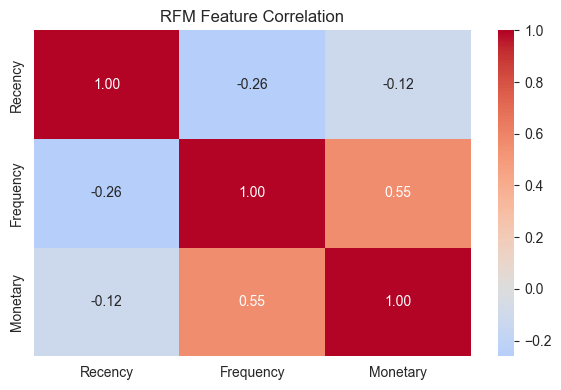

In [10]:
# Correlation heatmap of raw RFM values
plt.figure(figsize=(6, 4))
sns.heatmap(rfm[['Recency', 'Frequency', 'Monetary']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('RFM Feature Correlation')
plt.tight_layout()
plt.show()

## Step 6 — Outlier Removal & Feature Scaling

- **Outlier removal** using IQR method on Recency, Frequency, and Monetary.
- **Log transformation** applied to Frequency and Monetary (right-skewed distributions) to normalize.
- **RobustScaler** used for scaling — less sensitive to remaining outliers than StandardScaler.

In [11]:
def remove_outliers_iqr(dataframe, columns):
    """Remove rows where any of the specified columns are outside 1.5*IQR bounds."""
    df_out = dataframe.copy()
    for col in columns:
        Q1  = df_out[col].quantile(0.25)
        Q3  = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower  = Q1 - 1.5 * IQR
        upper  = Q3 + 1.5 * IQR
        before = len(df_out)
        df_out = df_out[(df_out[col] >= lower) & (df_out[col] <= upper)]
        print(f'  {col}: removed {before - len(df_out)} outliers (bounds [{lower:.1f}, {upper:.1f}])')
    return df_out

print('Removing outliers via IQR:')
rfm_clean = remove_outliers_iqr(rfm, ['Recency', 'Frequency', 'Monetary'])
print(f'\nShape before: {rfm.shape}  →  after: {rfm_clean.shape}')

Removing outliers via IQR:
  Recency: removed 155 outliers (bounds [-168.0, 328.0])
  Frequency: removed 284 outliers (bounds [-5.0, 11.0])
  Monetary: removed 297 outliers (bounds [-1340.5, 3049.2])

Shape before: (4338, 4)  →  after: (3602, 4)


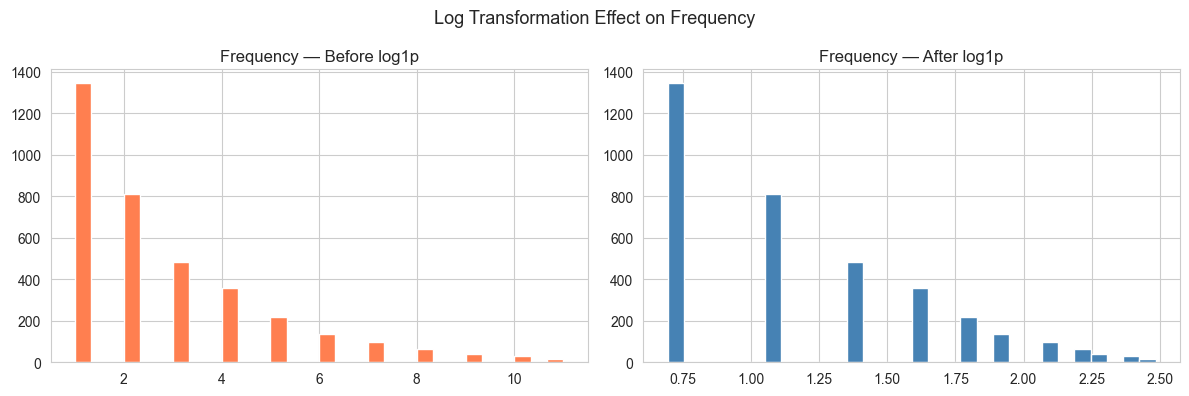

In [12]:
# Log-transform skewed features (Frequency & Monetary)
# log1p is used (log(1+x)) to handle zero values safely
rfm_log = rfm_clean.copy()
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm_log['Monetary'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rfm_clean['Frequency'], bins=30, color='coral', edgecolor='white')
axes[0].set_title('Frequency — Before log1p')
axes[1].hist(rfm_log['Frequency'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Frequency — After log1p')
plt.suptitle('Log Transformation Effect on Frequency', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Scale using RobustScaler (median + IQR based — handles outliers better)
features = ['Recency', 'Frequency', 'Monetary']

scaler = RobustScaler()
rfm_scaled = scaler.fit_transform(rfm_log[features])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=features, index=rfm_log.index)

print('Scaled RFM Statistics:')
rfm_scaled_df.describe().round(3)

Scaled RFM Statistics:


,Recency,Frequency,Monetary
count,3602.000,3602.000,3602.000
mean,0.282,0.097,-0.047
std,0.729,0.527,0.699
min,-0.456,-0.443,-3.498
25%,-0.285,-0.443,-0.509
50%,0.000,0.000,-0.000
75%,0.715,0.557,0.491
max,2.200,1.513,1.200


## Step 7 — Model Training

We train three clustering algorithms:

| Algorithm | Type | Key Hyperparameter |
|-----------|------|--------------------|
| **KMeans** | Centroid-based | `k` (number of clusters) |
| **Agglomerative (Hierarchical)** | Linkage-based | `n_clusters`, `linkage` |
| **DBSCAN** | Density-based | `eps`, `min_samples` |

### 7a — KMeans Clustering: Elbow Method & Silhouette Score

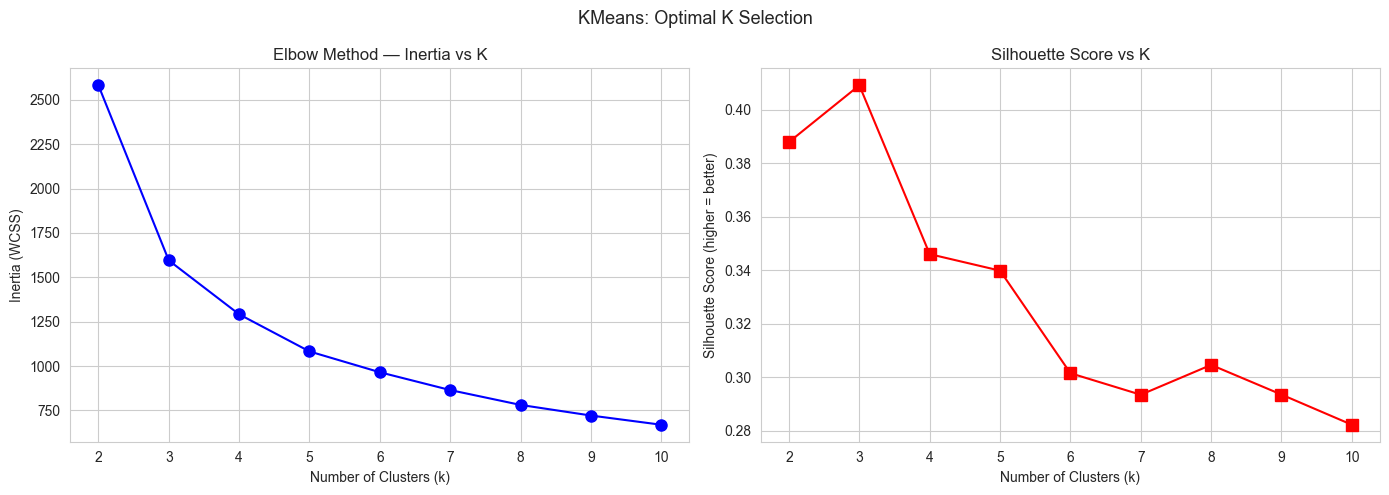


✅ Best K by Silhouette Score: 3  (score = 0.4092)


In [14]:
# Elbow Method — find optimal k by plotting inertia (within-cluster sum of squares)
inertias    = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(rfm_scaled_df)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled_df, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(K_range, inertias, 'bo-', markersize=8)
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_xticks(list(K_range))

# Silhouette score curve
axes[1].plot(K_range, silhouettes, 'rs-', markersize=8)
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].set_xticks(list(K_range))

plt.suptitle('KMeans: Optimal K Selection', fontsize=13)
plt.tight_layout()
plt.show()

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f'\n✅ Best K by Silhouette Score: {best_k}  (score = {max(silhouettes):.4f})')

In [15]:
# Train final KMeans with best k
kmeans = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(rfm_scaled_df)

rfm_clean['KMeans_Cluster'] = kmeans_labels

km_silhouette = silhouette_score(rfm_scaled_df, kmeans_labels)
km_db_score   = davies_bouldin_score(rfm_scaled_df, kmeans_labels)

print(f'KMeans (k={best_k})')
print(f'  Silhouette Score    : {km_silhouette:.4f}  (closer to 1 is better)')
print(f'  Davies-Bouldin Score: {km_db_score:.4f}  (lower is better)')
print(f'\nCluster Sizes:\n{pd.Series(kmeans_labels).value_counts().sort_index()}')

KMeans (k=3)
  Silhouette Score    : 0.4092  (closer to 1 is better)
  Davies-Bouldin Score: 0.8695  (lower is better)

Cluster Sizes:
0    1464
1    1285
2     853
Name: count, dtype: int64


### 7b — Hierarchical (Agglomerative) Clustering

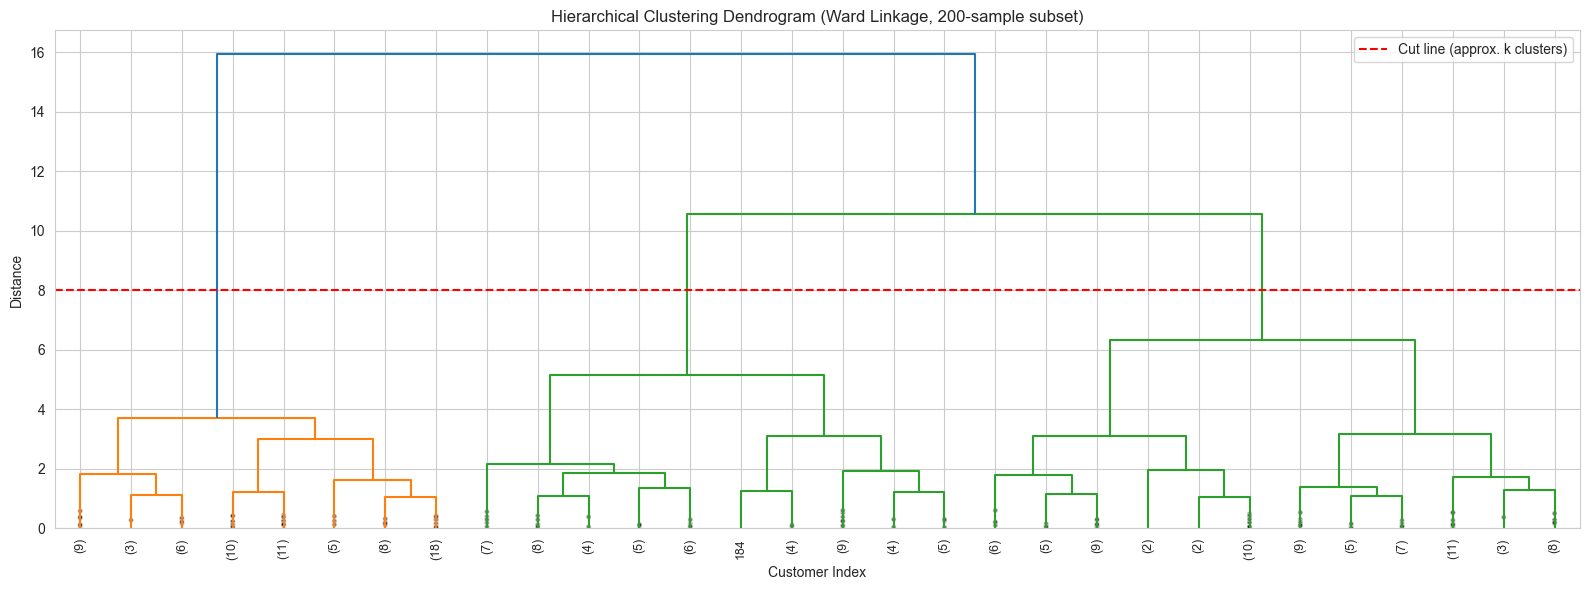

In [16]:
# Dendrogram — visualizes the merging hierarchy
# Using a sample of 200 customers for visual clarity
sample_idx = np.random.choice(len(rfm_scaled_df), size=200, replace=False)
sample_data = rfm_scaled_df.iloc[sample_idx]

Z = linkage(sample_data, method='ward')  # Ward minimizes within-cluster variance

plt.figure(figsize=(16, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=9, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, 200-sample subset)')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.axhline(y=8, color='red', linestyle='--', label='Cut line (approx. k clusters)')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Train Agglomerative Clustering with same k as KMeans for fair comparison
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg.fit_predict(rfm_scaled_df)

rfm_clean['Hierarchical_Cluster'] = agg_labels

agg_silhouette = silhouette_score(rfm_scaled_df, agg_labels)
agg_db_score   = davies_bouldin_score(rfm_scaled_df, agg_labels)

print(f'Agglomerative Clustering (k={best_k}, Ward linkage)')
print(f'  Silhouette Score    : {agg_silhouette:.4f}')
print(f'  Davies-Bouldin Score: {agg_db_score:.4f}')
print(f'\nCluster Sizes:\n{pd.Series(agg_labels).value_counts().sort_index()}')

Agglomerative Clustering (k=3, Ward linkage)
  Silhouette Score    : 0.3847
  Davies-Bouldin Score: 0.8583

Cluster Sizes:
0    1759
1     958
2     885
Name: count, dtype: int64


### 7c — DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) does not require specifying `k` upfront.  
It discovers clusters of arbitrary shape and labels noise points as **-1**.  

**Key hyperparameters:**
- `eps`: radius of the neighborhood (use k-distance graph to estimate)
- `min_samples`: minimum points within eps to form a core point

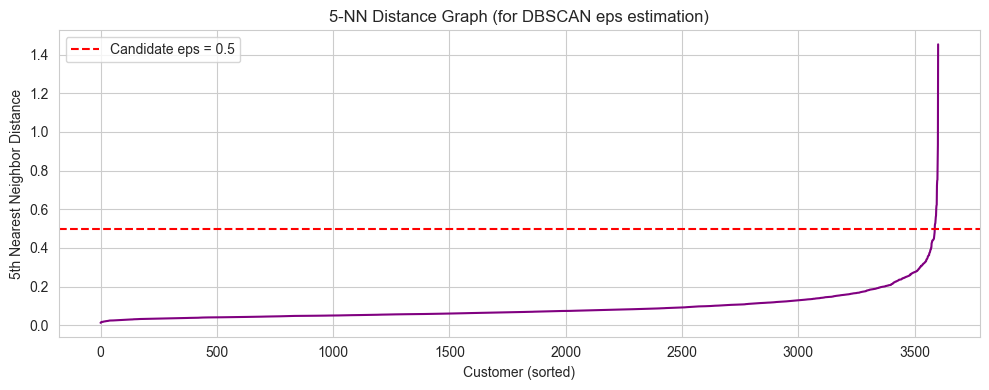

The "elbow" in the k-distance graph suggests a good eps value.


In [18]:
from sklearn.neighbors import NearestNeighbors

# k-distance graph to estimate optimal eps
# We use k = min_samples - 1 = 4 (a common default for 3D data: 2*dims)
k_neighbors = 5
nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(rfm_scaled_df)
distances, _ = nbrs.kneighbors(rfm_scaled_df)

# Sort the 5th-NN distances in ascending order
kth_dist = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(kth_dist, color='purple')
plt.axhline(y=0.5, color='red', linestyle='--', label='Candidate eps = 0.5')
plt.title(f'{k_neighbors}-NN Distance Graph (for DBSCAN eps estimation)')
plt.xlabel('Customer (sorted)')
plt.ylabel(f'{k_neighbors}th Nearest Neighbor Distance')
plt.legend()
plt.tight_layout()
plt.show()
print('The "elbow" in the k-distance graph suggests a good eps value.')

In [19]:
# Train DBSCAN — tune eps based on the k-distance plot elbow
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(rfm_scaled_df)

rfm_clean['DBSCAN_Cluster'] = dbscan_labels

n_clusters_db  = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db     = list(dbscan_labels).count(-1)
noise_pct      = (n_noise_db / len(dbscan_labels)) * 100

print(f'DBSCAN (eps=0.5, min_samples=5)')
print(f'  Clusters found     : {n_clusters_db}')
print(f'  Noise points       : {n_noise_db} ({noise_pct:.1f}% of customers)')

if n_clusters_db > 1:
    # Silhouette only valid if > 1 cluster and not all noise
    mask = dbscan_labels != -1
    if mask.sum() > 1:
        db_silhouette = silhouette_score(rfm_scaled_df[mask], dbscan_labels[mask])
        print(f'  Silhouette Score   : {db_silhouette:.4f}  (computed excluding noise)')
else:
    print('  ⚠️  Only 1 cluster found — adjust eps or min_samples')

print(f'\nCluster Sizes (−1 = noise):\n{pd.Series(dbscan_labels).value_counts().sort_index()}')

DBSCAN (eps=0.5, min_samples=5)
  Clusters found     : 1
  Noise points       : 4 (0.1% of customers)
  ⚠️  Only 1 cluster found — adjust eps or min_samples

Cluster Sizes (−1 = noise):
-1       4
 0    3598
Name: count, dtype: int64


## Step 8 — Model Comparison

In [20]:
# Summary comparison table
results = {
    'Algorithm'        : ['KMeans', 'Agglomerative (Ward)', 'DBSCAN'],
    'N Clusters'       : [best_k, best_k, n_clusters_db],
    'Silhouette Score' : [round(km_silhouette, 4),
                          round(agg_silhouette, 4),
                          round(db_silhouette if n_clusters_db > 1 else 0, 4)],
    'Davies-Bouldin'   : [round(km_db_score, 4), round(agg_db_score, 4), 'N/A']
}

results_df = pd.DataFrame(results)
print('\n📊 Clustering Algorithm Comparison:')
print(results_df.to_string(index=False))

print('\n🏆 Best model by Silhouette Score: KMeans (generally most interpretable for RFM)')


📊 Clustering Algorithm Comparison:
           Algorithm  N Clusters  Silhouette Score Davies-Bouldin
              KMeans           3            0.4092         0.8695
Agglomerative (Ward)           3            0.3847         0.8583
              DBSCAN           1            0.0000            N/A

🏆 Best model by Silhouette Score: KMeans (generally most interpretable for RFM)


## Step 9 — Dimensionality Reduction: PCA & t-SNE

Since RFM is 3D, we can directly visualize with PCA (2 components) and t-SNE.  
We use the **KMeans labels** for coloring as they gave the best silhouette score.

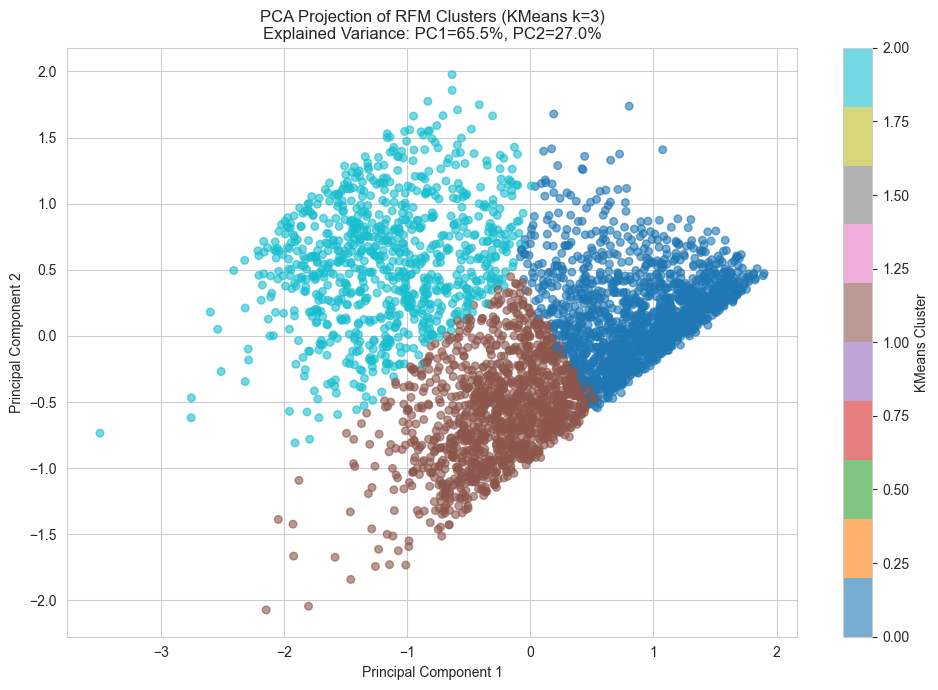

Total variance explained by 2 PCs: 92.5%


In [21]:
# PCA — Linear dimensionality reduction
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(rfm_scaled_df)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_components[:, 0], pca_components[:, 1],
                      c=kmeans_labels, cmap=PALETTE, alpha=0.6, s=30)
plt.colorbar(scatter, label='KMeans Cluster')
plt.title(f'PCA Projection of RFM Clusters (KMeans k={best_k})\n'
          f'Explained Variance: PC1={pca.explained_variance_ratio_[0]:.1%}, '
          f'PC2={pca.explained_variance_ratio_[1]:.1%}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

print(f'Total variance explained by 2 PCs: {sum(pca.explained_variance_ratio_):.1%}')

PCA Loadings (contribution of each RFM feature):
             PC1    PC2
Recency   -0.606  0.790
Frequency  0.467  0.254
Monetary   0.645  0.558


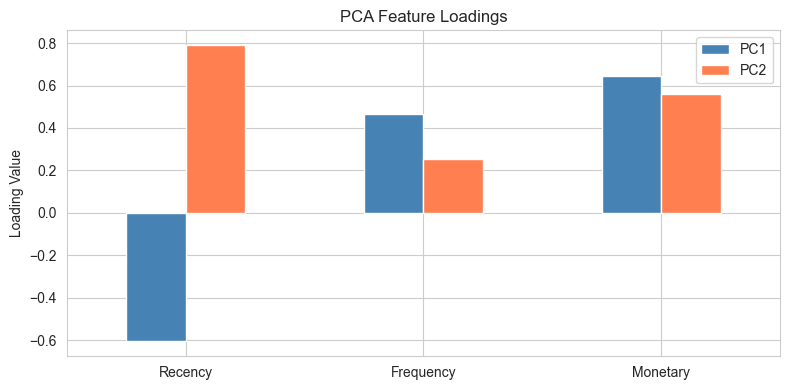

In [22]:
# PCA Component Loadings — how much each RFM feature contributes
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=['Recency', 'Frequency', 'Monetary'],
    columns=['PC1', 'PC2']
)

print('PCA Loadings (contribution of each RFM feature):')
print(loadings_df.round(3))

loadings_df.plot(kind='bar', figsize=(8, 4), color=['steelblue', 'coral'], edgecolor='white')
plt.title('PCA Feature Loadings')
plt.ylabel('Loading Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

⏳ Running t-SNE (this may take ~30 seconds)...


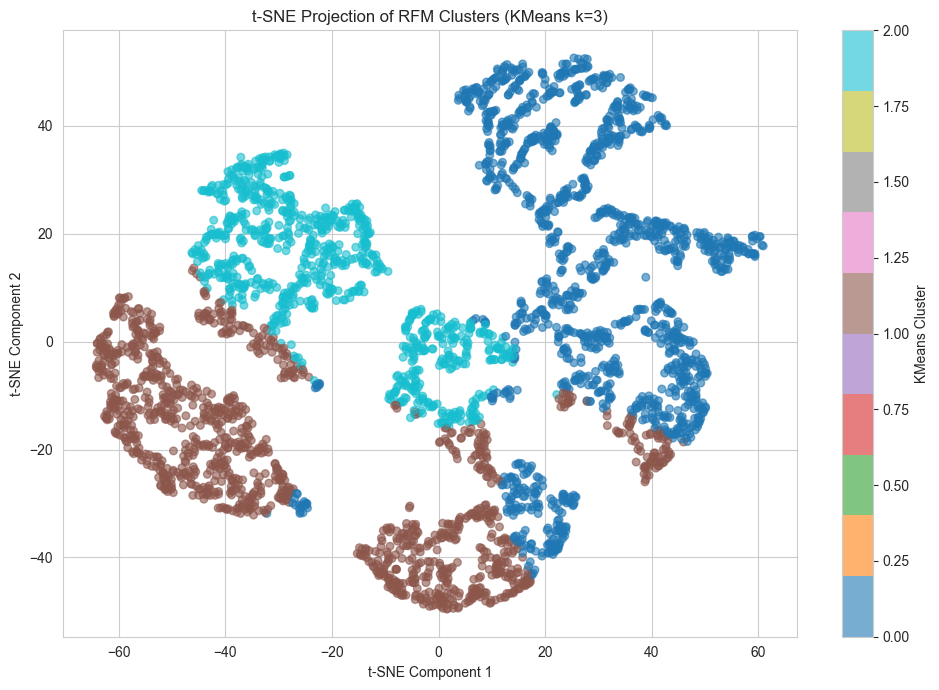

✅ t-SNE complete!


In [23]:
# t-SNE — Non-linear dimensionality reduction (better for revealing local structure)
# perplexity ~ sqrt(n_samples) is a common heuristic; we use 40
print('⏳ Running t-SNE (this may take ~30 seconds)...')

tsne = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42)
tsne_components = tsne.fit_transform(rfm_scaled_df)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(tsne_components[:, 0], tsne_components[:, 1],
                      c=kmeans_labels, cmap=PALETTE, alpha=0.6, s=30)
plt.colorbar(scatter, label='KMeans Cluster')
plt.title(f't-SNE Projection of RFM Clusters (KMeans k={best_k})')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()
print('✅ t-SNE complete!')

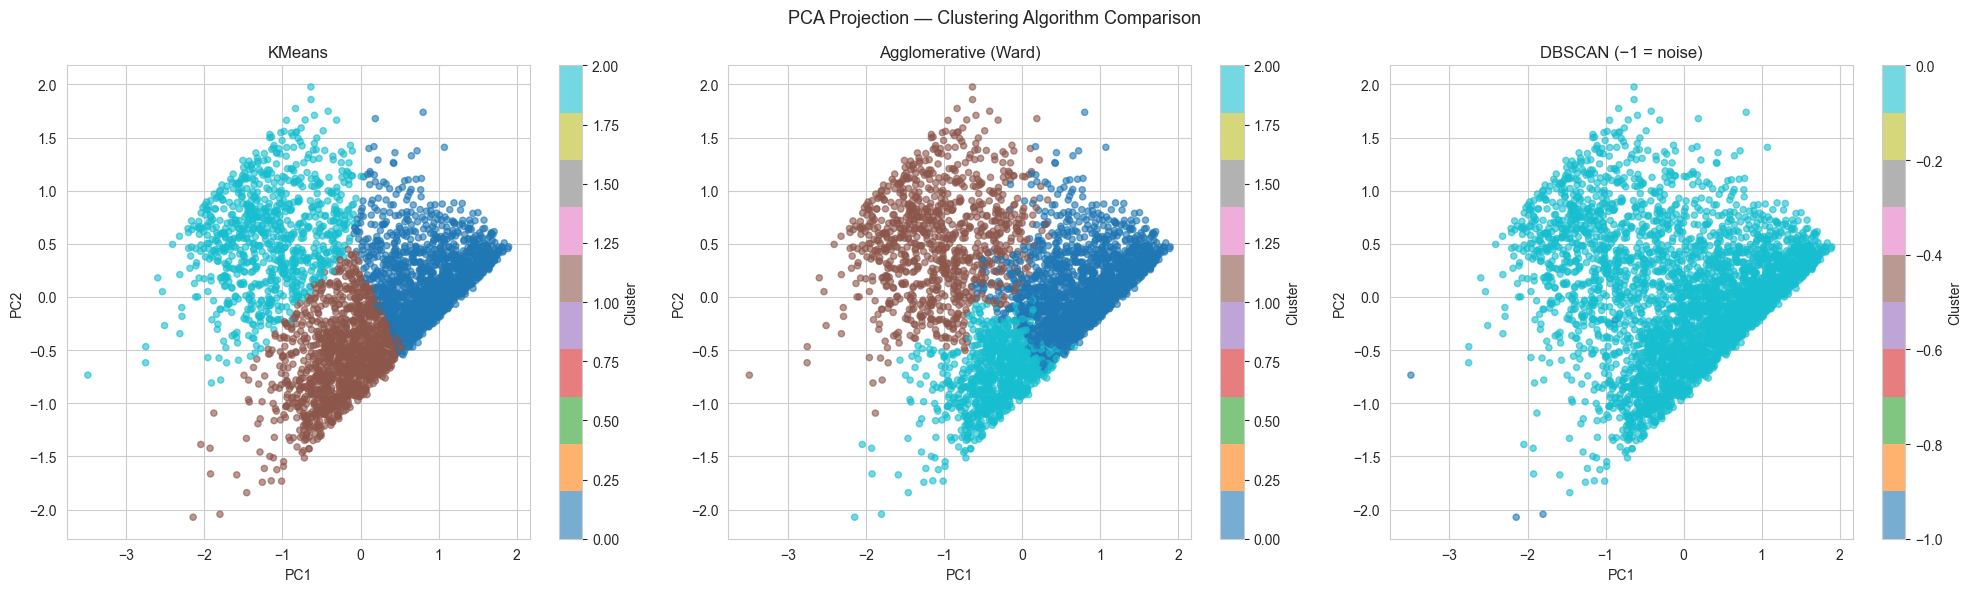

In [24]:
# Side-by-side: KMeans vs Hierarchical cluster labels on PCA space
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

label_sets = [
    (kmeans_labels,  'KMeans'),
    (agg_labels,     'Agglomerative (Ward)'),
    (dbscan_labels,  'DBSCAN (−1 = noise)')
]

for ax, (labels, title) in zip(axes, label_sets):
    sc = ax.scatter(pca_components[:, 0], pca_components[:, 1],
                    c=labels, cmap=PALETTE, alpha=0.6, s=20)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.colorbar(sc, ax=ax, label='Cluster')

plt.suptitle('PCA Projection — Clustering Algorithm Comparison', fontsize=13)
plt.tight_layout()
plt.show()

## Step 10 — Cluster Profiling & Business Insights

We profile each KMeans cluster by computing the **mean RFM values** per cluster on the original (unscaled) data.  
This lets us translate technical cluster IDs into actionable business personas.

In [25]:
# Merge cluster labels back with original RFM values
profile_df = rfm_clean.copy()

# Aggregate mean RFM per KMeans cluster
cluster_summary = profile_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
cluster_summary['Count'] = profile_df['KMeans_Cluster'].value_counts().sort_index()
cluster_summary['% of Customers'] = (cluster_summary['Count'] / len(profile_df) * 100).round(1)

print('📊 Cluster Profiles (Mean RFM Values per Cluster):')
print(cluster_summary.to_string())

📊 Cluster Profiles (Mean RFM Values per Cluster):
                Recency  Frequency  Monetary  Count  % of Customers
KMeans_Cluster                                                     
0                 43.13       4.52   1450.79   1464            40.6
1                 53.21       1.51    367.78   1285            35.7
2                232.74       1.47    390.15    853            23.7


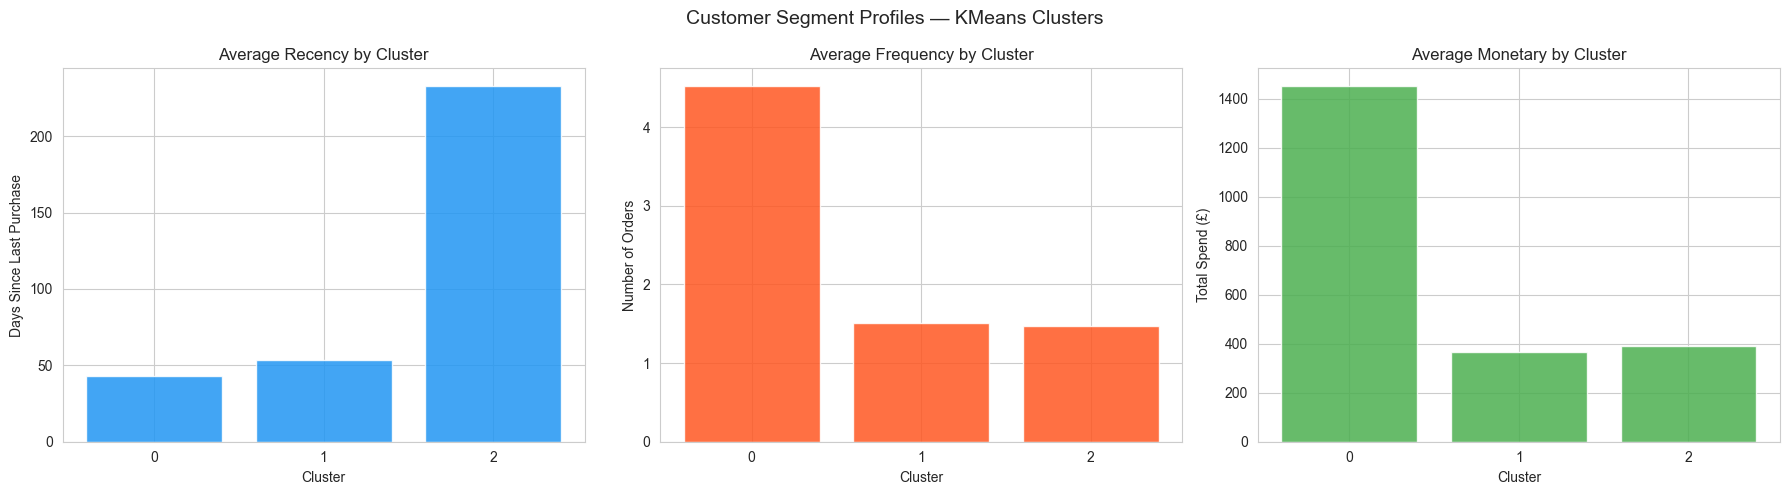

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Recency', 'Frequency', 'Monetary']
colors  = ['#2196F3', '#FF5722', '#4CAF50']
labels  = ['Days Since Last Purchase', 'Number of Orders', 'Total Spend (£)']

for ax, metric, color, ylabel in zip(axes, metrics, colors, labels):
    ax.bar(cluster_summary.index.astype(str),
           cluster_summary[metric], color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Average {metric} by Cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(ylabel)

plt.suptitle('Customer Segment Profiles — KMeans Clusters', fontsize=14)
plt.tight_layout()
plt.show()

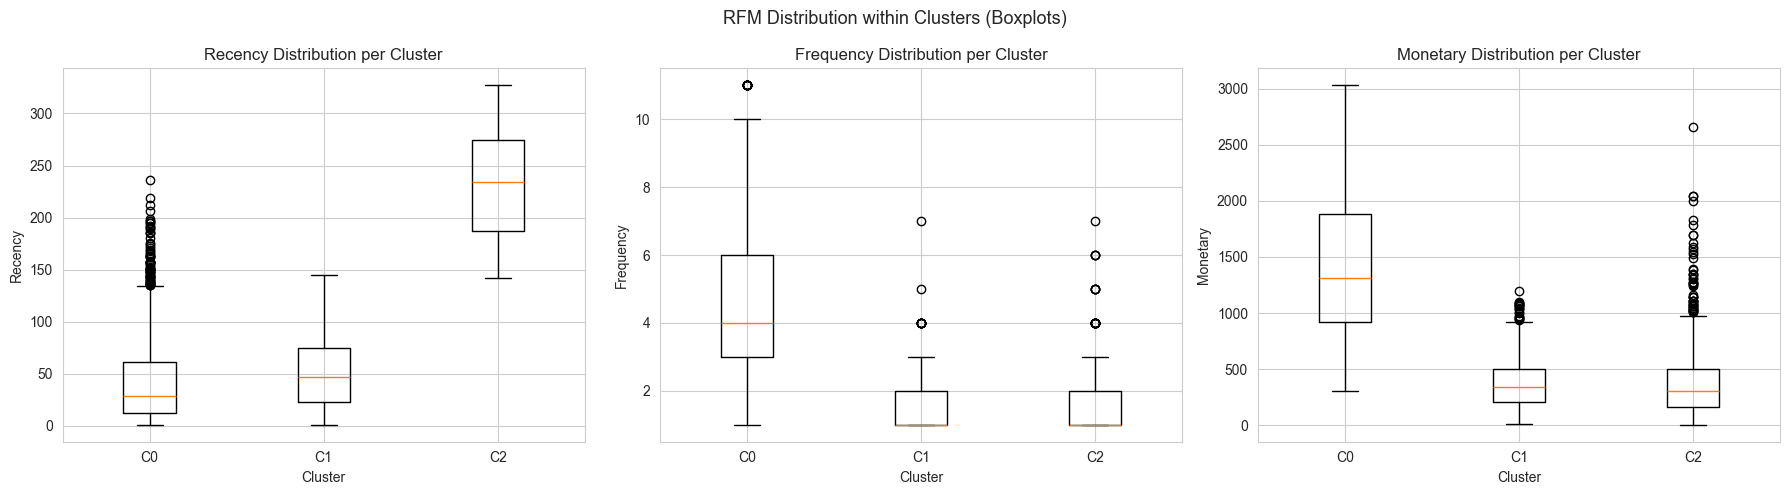

In [27]:
# Box plots showing RFM distribution within each cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    groups = [profile_df[profile_df['KMeans_Cluster'] == c][metric].values
              for c in sorted(profile_df['KMeans_Cluster'].unique())]
    ax.boxplot(groups, labels=[f'C{c}' for c in sorted(profile_df['KMeans_Cluster'].unique())])
    ax.set_title(f'{metric} Distribution per Cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(metric)

plt.suptitle('RFM Distribution within Clusters (Boxplots)', fontsize=13)
plt.tight_layout()
plt.show()

Customer Personas:
Persona
VIP                  1078
Dormant Customers     927
At Risk               866
Onboarders            417
Loyal Customers       314
Name: count, dtype: int64


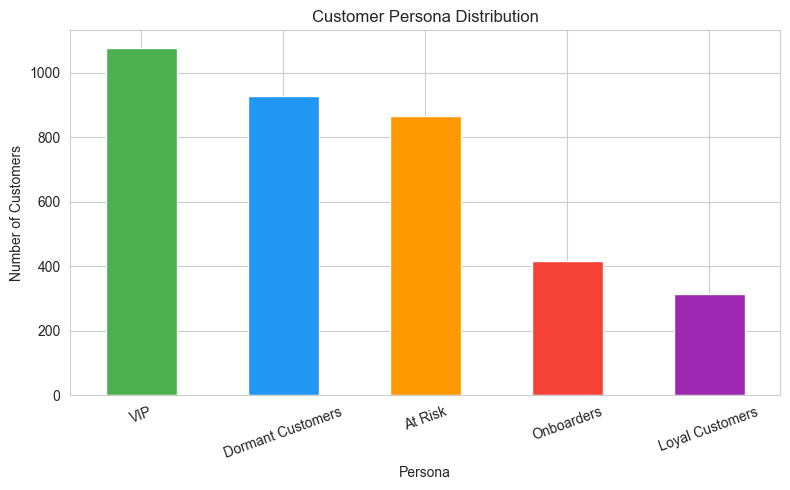

In [28]:
# Assign business persona labels based on RFM profile
# Logic:
#   Champions   = low recency, high frequency, high monetary
#   Loyal       = moderate recency, high frequency
#   At Risk     = high recency (haven't bought recently), previously active
#   Lost/Dormant= very high recency, low frequency/monetary
#   New / Potential = recent first-timers or low frequency but recent

def assign_persona(row):
    """Rule-based persona assignment using cluster mean RFM profile."""
    R = row['Recency']
    F = row['Frequency']
    M = row['Monetary']

    # Thresholds derived from dataset quartiles
    R_med = rfm_clean['Recency'].median()
    F_med = rfm_clean['Frequency'].median()
    M_med = rfm_clean['Monetary'].median()

    if R <= R_med and F >= F_med and M >= M_med:
        return 'VIP'
    elif R <= R_med and F >= F_med:
        return 'Loyal Customers'
    elif R <= R_med and F < F_med:
        return 'Onboarders'
    elif R > R_med and F >= F_med:
        return 'At Risk'
    else:
        return 'Dormant Customers'

profile_df['Persona'] = profile_df.apply(assign_persona, axis=1)

persona_counts = profile_df['Persona'].value_counts()
print('Customer Personas:')
print(persona_counts)

plt.figure(figsize=(8, 5))
persona_counts.plot(kind='bar', color=['#4CAF50','#2196F3','#FF9800','#F44336','#9C27B0'],
                    edgecolor='white')
plt.title('Customer Persona Distribution')
plt.xlabel('Persona')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

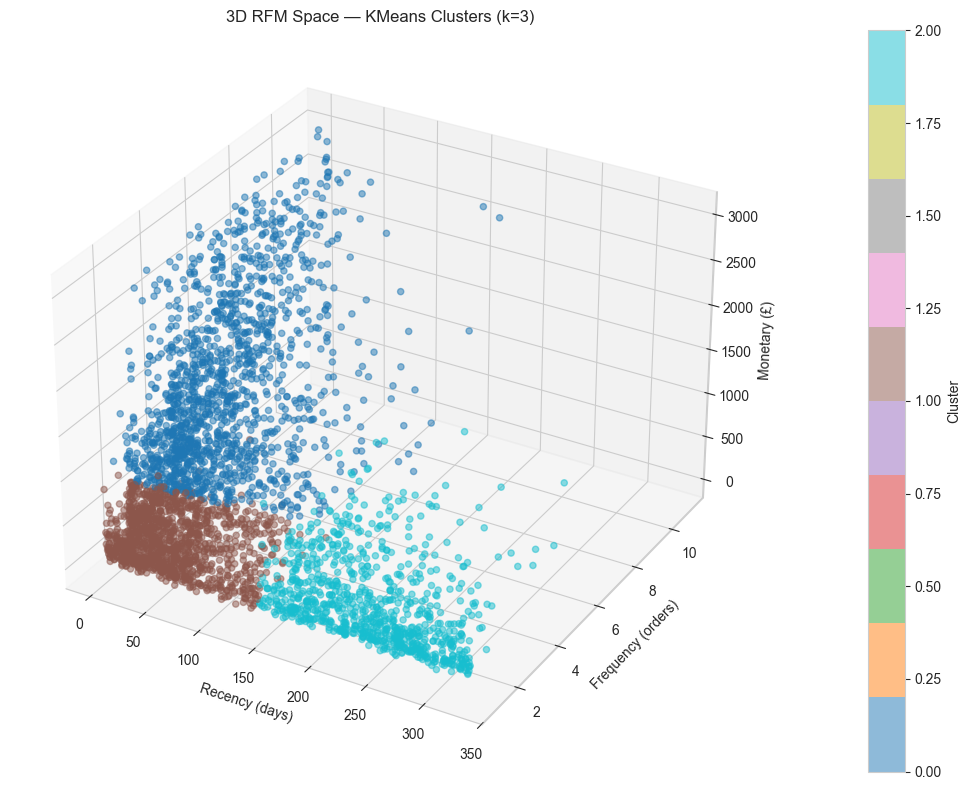

In [29]:
# 3D Scatter Plot of RFM space (coloured by KMeans cluster)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    profile_df['Recency'],
    profile_df['Frequency'],
    profile_df['Monetary'],
    c=profile_df['KMeans_Cluster'],
    cmap=PALETTE, alpha=0.5, s=20
)

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (orders)')
ax.set_zlabel('Monetary (£)')
ax.set_title(f'3D RFM Space — KMeans Clusters (k={best_k})')

plt.colorbar(scatter, ax=ax, pad=0.1, label='Cluster')
plt.tight_layout()
plt.show()

## Step 11 — Business Recommendations

Based on the segmentation, here are targeted strategies for each customer persona:

| Persona | Characteristics | Recommended Action |
|---------|----------------|--------------------|
| 🏆 **Champions** | Recent, frequent, high spend | Reward loyalty programs, early access to new products |
| 💙 **Loyal Customers** | Frequent buyers, moderate spend | Upsell premium products, referral programs |
| 🌱 **Promising / New** | Recent first buyers | Onboarding campaigns, welcome discounts |
| ⚠️ **At Risk** | Were active, haven't bought recently | Win-back emails, personalized offers |
| 💤 **Lost / Dormant** | Long since last purchase | Reactivation campaigns with steep discounts |

---

### 📝 Pipeline Summary

| Stage | Technique Used |
|-------|---------------|
| Data Cleaning | Remove missing CustomerIDs, cancellations, invalid rows |
| Feature Engineering | RFM (Recency, Frequency, Monetary) |
| Outlier Handling | IQR method + log1p transformation |
| Scaling | RobustScaler |
| Clustering | KMeans (k-means++), Agglomerative (Ward), DBSCAN |
| Evaluation | Silhouette Score, Davies-Bouldin Score, Elbow Method |
| Visualization | PCA (2D), t-SNE, 3D scatter, boxplots |
| Profiling | Cluster mean RFM + rule-based persona assignment |

In [35]:
# Export final segmented customer data
output_cols = ['CustomerID', 'Recency', 'Frequency', 'Monetary',
               'KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster', 'Persona']

final_output = profile_df[output_cols]
final_output.to_csv('customer_segments.csv', index=False)

print('✅ Segmentation complete! Results saved to customer_segments.csv')
print(f'Total customers segmented: {len(final_output)}')
final_output.head(10)

✅ Segmentation complete! Results saved to customer_segments.csv
Total customers segmented: 3602


,CustomerID,Recency,Frequency,Monetary,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster,Persona
2,12348,75,4,1797.24,0,0,0,At Risk
3,12349,19,1,1757.55,0,0,0,Promising / New
4,12350,310,1,334.40,2,1,0,Lost / Dormant
5,12352,36,8,2506.04,0,0,0,Champions
6,12353,204,1,89.00,2,1,0,Lost / Dormant
7,12354,232,1,1079.40,2,1,0,Lost / Dormant
8,12355,214,1,459.40,2,1,0,Lost / Dormant
9,12356,23,3,2811.43,0,0,0,Champions
11,12358,2,2,1168.06,0,0,0,Champions
13,12360,52,3,2662.06,0,0,0,Champions
